# Deteccion de Caracteristicas

In [1]:
#Importar Librerias

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import glob

#Crear los detectores

akaze = cv2.AKAZE_create()
orb = cv2.ORB_create()

# Agregar las Imagenes

In [2]:
notebook_dir = os.getcwd()
image_folder = os.path.join(notebook_dir)
image_files = glob.glob(os.path.join(image_folder, '*.jpg'))

if not image_files:
        print("No se encontraron imagenes.", image_folder)

No se encontraron imagenes. c:\Users\Usuario\Documents\Docs\Trabajos\Vision por Computador\Entrega2\CopySecurity


# Detector Orb

In [3]:
def Orb_Detector():

    num_images = len(image_files)
    plt.figure(figsize=(5 * num_images, 5))

    for i, image in enumerate(image_files):
        img = cv2.imread(image)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        kp_orb, des_orb = orb.detectAndCompute(img_gray, None)
        img_orb = cv2.drawKeypoints(img, kp_orb, None, color=(0,255,0), flags=0)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
        plt.title(f"ORB detecto - {len(kp_orb)} puntos")
        plt.axis('off')
    plt.suptitle("Orb")
    plt.show()


# Detector Akaze

In [4]:
def Akaze_Detector():

    num_images = len(image_files)
    plt.figure(figsize=(5 * num_images, 5))

    for i, image in enumerate(image_files):
        img = cv2.imread(image)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        kp_akaze, des_akaze = akaze.detectAndCompute(img_gray, None)
        img_akaze = cv2.drawKeypoints(img, kp_akaze, None, color=(0,255,0), flags=0)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(cv2.cvtColor(img_akaze, cv2.COLOR_BGR2RGB))
        plt.title(f"Akaze detecto - {len(kp_akaze)} puntos")
        plt.axis('off')
    plt.suptitle("Akaze")
    plt.show()

# Ejecutamos los Detectores

In [5]:
img1 = cv2.imread(image_files[0])
img2 = cv2.imread(image_files[1])
img3 = cv2.imread(image_files[2])

#Rotamos la imagen 2

# Obtener dimensiones
(h, w) = img2.shape[:2]
center = (w // 2, h // 2)  # Centro de la imagen

# Matriz de rotación (ángulo negativo para rotar a la derecha)
angle = -15  # derecha -> negativo, izquierda -> positivo
scale = 1.0
M = cv2.getRotationMatrix2D(center, angle, scale)

# Aplicar rotación
img2 = cv2.warpAffine(img2, M, (w, h))

plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title(f"Rotada {abs(angle)}° a la derecha")
plt.axis('off')

plt.show()

#Rotamos la Imagen 3

# Obtener dimensiones
(h, w) = img3.shape[:2]
center = (w // 2, h // 2)  # Centro de la imagen

# Matriz de rotación (ángulo negativo para rotar a la derecha)
angle = -31.5  # derecha -> negativo, izquierda -> positivo
scale = 1.0
M = cv2.getRotationMatrix2D(center, angle, scale)

# Aplicar rotación
img3 = cv2.warpAffine(img3, M, (w, h))

plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.title(f"Rotada {abs(angle)}° a la derecha")
plt.axis('off')

plt.show()

# Llamamos los detectores
Akaze_Detector()
Orb_Detector()

# Emparejamiento

def Emparejamiento(image1, image2, detector, detector_txt):

    # Detectar keypoints y descriptores
    kp1, des1 = detector.detectAndCompute(image1, None)
    kp2, des2 = detector.detectAndCompute(image2, None)

    if des1 is None or des2 is None:
        print("No se detectaron suficientes características en una de las imágenes")
        return None, None, None, None

    # Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)

    # Lowe's Ratio Test
    good_matches = []
    for m_n in matches:
        if len(m_n) == 2:
            m, n = m_n
            if m.distance < 1.5 * n.distance:
                good_matches.append(m)
    
    print(f"[{detector_txt}] Características detectadas: {len(kp1)} en img1, {len(kp2)} en img2")
    print(f"[{detector_txt}] Matches buenos: {len(good_matches)}")
    
    if len(good_matches) < 4:
        print(f"[{detector_txt}] Insuficientes matches para calcular homografía")
        return None, None, None, None
    
    # Extraer puntos
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    # Calcular Homografía con RANSAC
    H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
    inliers = mask.ravel().tolist() if mask is not None else []
    print(f"[{detector_txt}] Inliers (RANSAC): {sum(inliers)}/{len(inliers)}")
    
    # Dibujar matches
    img_matches = cv2.drawMatches(
        image1, kp1, image2, kp2, good_matches, None,
        matchesMask=inliers, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return H, pts1, pts2, img_matches

IndexError: list index out of range

# Logica Emparejamiento

[ORB] Características detectadas: 500 en img1, 500 en img2
[ORB] Matches buenos: 500
[ORB] Inliers (RANSAC): 154/500
[AKAZE] Características detectadas: 1186 en img1, 1640 en img2
[AKAZE] Matches buenos: 1186
[AKAZE] Inliers (RANSAC): 359/1186
[ORB] Características detectadas: 500 en img1, 500 en img2
[ORB] Matches buenos: 500
[ORB] Inliers (RANSAC): 84/500
[AKAZE] Características detectadas: 1186 en img1, 2934 en img2
[AKAZE] Matches buenos: 1186
[AKAZE] Inliers (RANSAC): 107/1186


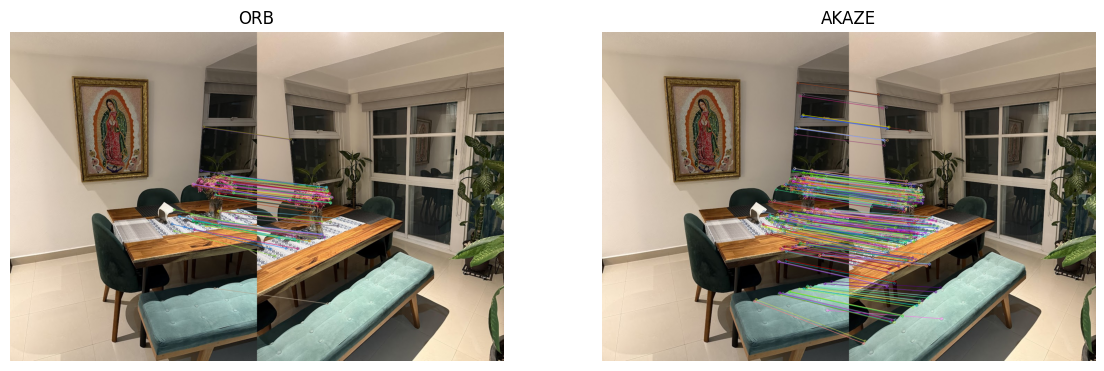

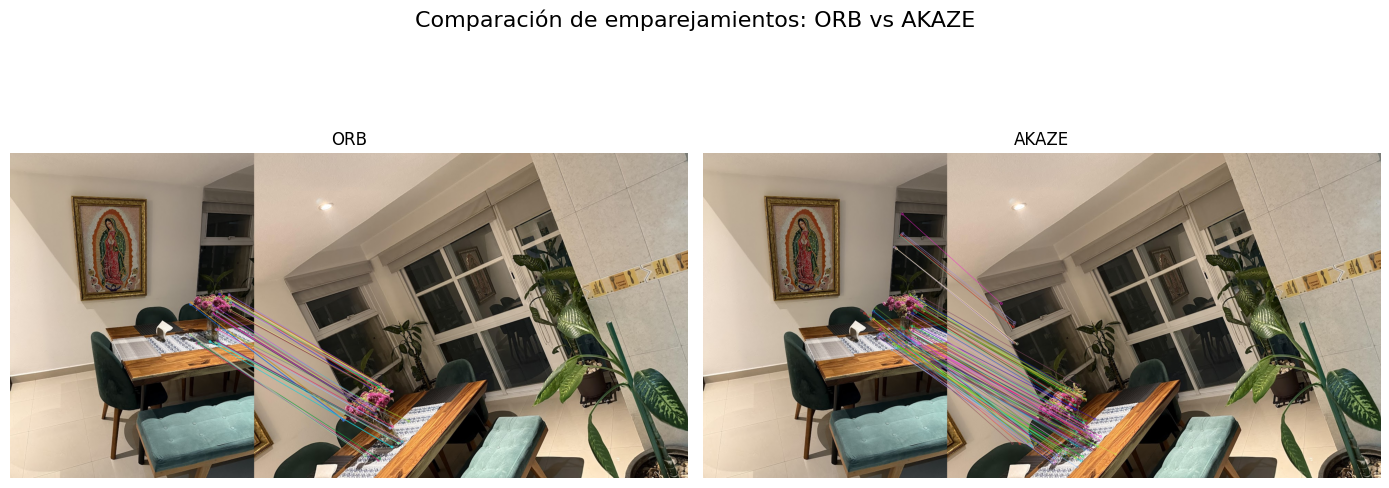

In [ ]:
#Dibujamos los Matches

ref_img = cv2.imread(image_files[0])

for i, img in enumerate(image_files[1:], start=1):
    
    img = cv2.imread(img)

    # ORB
    H_orb, prs1Orb, pts2Orb, img_match_orb = Emparejamiento(ref_img, img, orb, "ORB")

    # AKAZE
    H_akaze, prs1Ak, pts2Ak, img_match_akaze = Emparejamiento(ref_img, img, akaze, "AKAZE")

    plt.figure(figsize=(14, 6))

    if img_match_orb is not None:
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img_match_orb, cv2.COLOR_BGR2RGB))
        plt.title(f"ORB")
        plt.axis('off')

    if img_match_akaze is not None:
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(img_match_akaze, cv2.COLOR_BGR2RGB))
        plt.title(f"AKAZE")
        plt.axis('off')
plt.suptitle("Comparación de emparejamientos: ORB vs AKAZE", fontsize=16)
plt.tight_layout()
plt.show()

# Combinar las tres imagenes

In [ ]:
def bundle(H, pts_src, pts_dst, type="ORB"):
    try:
        # Recalcular homografía optimizada con método de reproyección robusto
        H_opt, _ = cv2.findHomography(pts_src, pts_dst, cv2.RANSAC, 3.0)
        print(f"Optimización de homografía completada para {type}")
        return H_opt if H_opt is not None else H
    except Exception as e:
        print(f"Error en la optimización de homografía ({type}): {e}")
        return H

[ORB] Características detectadas: 500 en img1, 500 en img2
[ORB] Matches buenos: 500
[ORB] Inliers (RANSAC): 136/500
Optimización de homografía completada para ORB


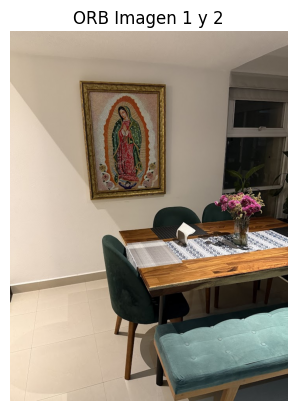

[ORB] Características detectadas: 500 en img1, 500 en img2
[ORB] Matches buenos: 500
[ORB] Inliers (RANSAC): 85/500
Optimización de homografía completada para ORB


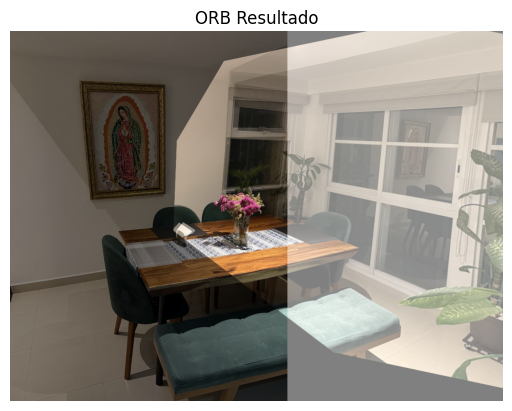

[AKAZE] Características detectadas: 1186 en img1, 1677 en img2
[AKAZE] Matches buenos: 1186
[AKAZE] Inliers (RANSAC): 338/1186
Optimización de homografía completada para AKAZE


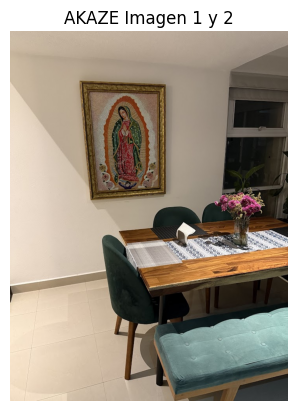

[AKAZE] Características detectadas: 1186 en img1, 2794 en img2
[AKAZE] Matches buenos: 1186
[AKAZE] Inliers (RANSAC): 116/1186
Optimización de homografía completada para AKAZE


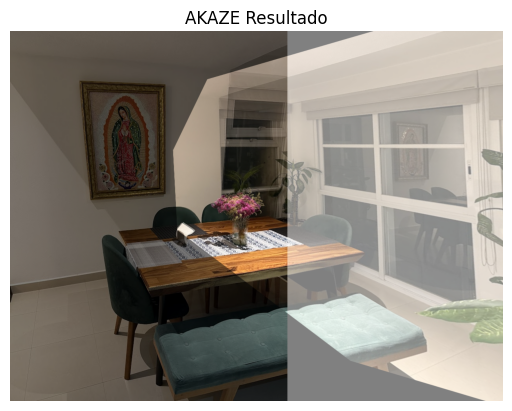

In [ ]:
def align_and_blend_mask(img1, img2, type, detector, alpha=0.5):

    # Emparejamiento
    H, pts1, pts2, matches_img = Emparejamiento(img1, img2, type, detector)
    
    # Bundle 
    H = bundle(H, pts1, pts2, detector)
    
    # Invert homography
    retval, H = cv2.invert(H)
    
    # Expandir el Canvas
    h_img1, w_img1 = img1.shape[:2]
    h_img2, w_img2 = img2.shape[:2]
    extra_width = max(0, w_img2 - w_img1)
    if extra_width > 0:
        img1 = cv2.copyMakeBorder(img1, 0, 0, 0, extra_width, cv2.BORDER_CONSTANT, value=[255,255,255])
    
    h_f, w_f = img1.shape[:2]
    
    # Warp
    img_lined = cv2.warpPerspective(img2, H, (w_f, h_f))
    
    # Blend imagenes
    result = cv2.addWeighted(img1, 1-alpha, img_lined, alpha, 0)
    
    return result, img_lined, H, matches_img

# ORB
result_orb, aligned_orb, H_orb, matches_orb = align_and_blend_mask(img1, img2, orb, "ORB", alpha=0)

plt.imshow(cv2.cvtColor(result_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB Imagen 1 y 2")
plt.axis('off')
plt.show()

result_orb, aligned_orb, H_orb, matches_orb = align_and_blend_mask(result_orb, img3, orb, "ORB", alpha=0.5)

plt.imshow(cv2.cvtColor(result_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB Resultado")
plt.axis('off')
plt.show()

# AKAZE
result_akaze, aligned_akaze, H_akaze, matches_akaze = align_and_blend_mask(img1, img2, akaze, "AKAZE", alpha=0)

plt.imshow(cv2.cvtColor(result_akaze, cv2.COLOR_BGR2RGB))
plt.title("AKAZE Imagen 1 y 2")
plt.axis('off')
plt.show()

result_akaze, aligned_akaze, H_akaze, matches_akaze = align_and_blend_mask(result_akaze, img3, akaze, "AKAZE", alpha=0.5)

plt.imshow(cv2.cvtColor(result_akaze, cv2.COLOR_BGR2RGB))
plt.title("AKAZE Resultado")
plt.axis('off')
plt.show()